In [2]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.13.0+cpu
Using device: cpu


# Part 1

In [15]:
P1_X_MIN, P1_X_MAX = -4.0, 4.0
P1_Y_MIN, P1_Y_MAX = -4.0, 4.0
P1_SPACING = 0.01

GAUSSIAN_SIGMA = 1.0

WAVE_FREQUENCY = 5.0
WAVE_ANGLE_DEG = 0.0
WAVE_PHASE = 0.0

P1_FIGSIZE = (15, 4)


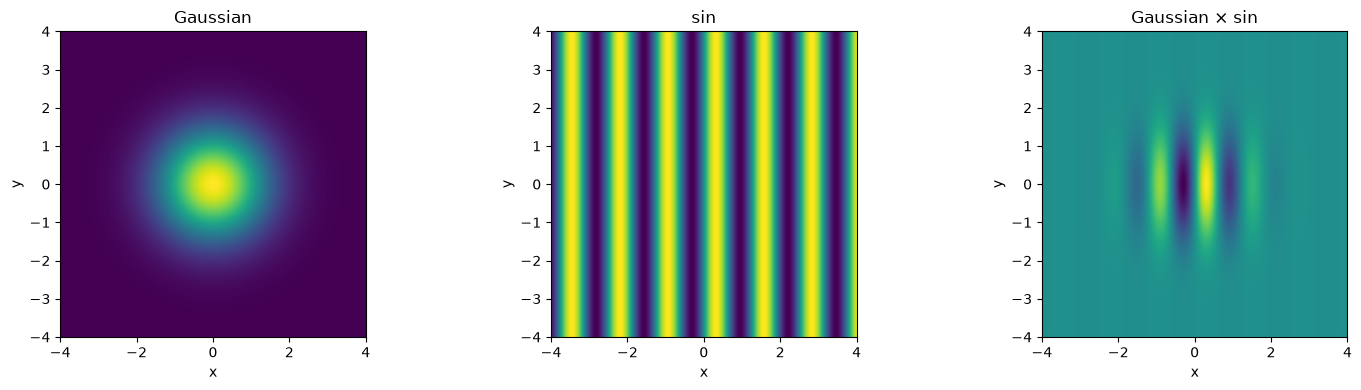

In [16]:
Y_np, X_np = np.mgrid[
    P1_Y_MIN:P1_Y_MAX:P1_SPACING,
    P1_X_MIN:P1_X_MAX:P1_SPACING
]

x = torch.tensor(X_np, dtype=torch.float32, device=device)
y = torch.tensor(Y_np, dtype=torch.float32, device=device)

gaussian = torch.exp(-(x**2 + y**2) / (2 * GAUSSIAN_SIGMA**2))

theta = math.radians(WAVE_ANGLE_DEG)
coordinate_along_wave = x * math.cos(theta) + y * math.sin(theta)
phase = WAVE_FREQUENCY * coordinate_along_wave + WAVE_PHASE
wave = torch.sin(phase)

gabor = gaussian * wave

fig, axes = plt.subplots(1, 3, figsize=P1_FIGSIZE)

extent = [P1_X_MIN, P1_X_MAX, P1_Y_MIN, P1_Y_MAX]

axes[0].imshow(gaussian.detach().cpu().numpy(), origin="lower", extent=extent)
axes[0].set_title("Gaussian")

axes[1].imshow(wave.detach().cpu().numpy(), origin="lower", extent=extent)
axes[1].set_title("sin")

axes[2].imshow(gabor.detach().cpu().numpy(), origin="lower", extent=extent)
axes[2].set_title("Gaussian × sin")

for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.tight_layout()
plt.show()


# Part 2 — Mandelbrot and Julia sets

For the Mandelbrot set, each pixel represents a complex number \(c\), and we iterate

\[
z_{n+1}=z_n^2+c, \qquad z_0=0.
\]

If \(|z_n|\) grows beyond an escape radius, the point is treated as diverging. The number of iterations before escape gives a useful colour value.

A **Julia set** uses the same recurrence but changes the roles:
- each pixel is the starting value \(z_0\);
- a single fixed complex constant \(c\) is used for every pixel.

The controls below make it easy to zoom, increase resolution and swap Julia constants during the demo.

In [5]:
MANDEL_X_MIN, MANDEL_X_MAX = -2.0, 1.0
MANDEL_Y_MIN, MANDEL_Y_MAX = -1.3, 1.3

MANDEL_SPACING = 0.004

MANDEL_MAX_ITER = 250
ESCAPE_RADIUS = 4.0

JULIA_X_MIN, JULIA_X_MAX = -1.7, 1.7
JULIA_Y_MIN, JULIA_Y_MAX = -1.3, 1.3
JULIA_SPACING = 0.004
JULIA_C = complex(-0.8, 0.156)
JULIA_MAX_ITER = 250

FRACTAL_FIGSIZE = (10, 7)

In [6]:
def escape_time_fractal(x_min, x_max, y_min, y_max, spacing,
                        max_iter=250, escape_radius=4.0,
                        mode="mandelbrot", julia_c=-0.8+0.156j):
    """Compute Mandelbrot or Julia escape-time counts using PyTorch."""

    # NumPy only creates the coordinate grid; iteration is done in PyTorch.
    Y_np, X_np = np.mgrid[y_min:y_max:spacing, x_min:x_max:spacing]

    x = torch.tensor(X_np, dtype=torch.float32, device=device)
    y = torch.tensor(Y_np, dtype=torch.float32, device=device)
    grid = torch.complex(x, y)

    if mode.lower() == "mandelbrot":
        z = torch.zeros_like(grid)
        c = grid
    elif mode.lower() == "julia":
        z = grid.clone()
        c = torch.full_like(grid, complex(julia_c))
    else:
        raise ValueError("mode must be 'mandelbrot' or 'julia'")

    # Counts how long each point remains bounded.
    counts = torch.zeros(grid.shape, dtype=torch.int32, device=device)
    active = torch.ones(grid.shape, dtype=torch.bool, device=device)

    for _ in range(max_iter):
        # Only update points that have not yet escaped.
        z_active = z[active]
        c_active = c[active]
        z[active] = z_active * z_active + c_active

        still_bounded = torch.abs(z) < escape_radius
        counts += still_bounded.int()

        new_active = active & still_bounded
        if not torch.any(new_active):
            break
        active = new_active

    return counts.detach().cpu().numpy()


def show_fractal(counts, x_min, x_max, y_min, y_max, title):
    plt.figure(figsize=FRACTAL_FIGSIZE)
    plt.imshow(
        counts,
        origin="lower",
        extent=[x_min, x_max, y_min, y_max],
        interpolation="nearest"
    )
    plt.title(title)
    plt.xlabel("Real")
    plt.ylabel("Imaginary")
    plt.tight_layout()
    plt.show()


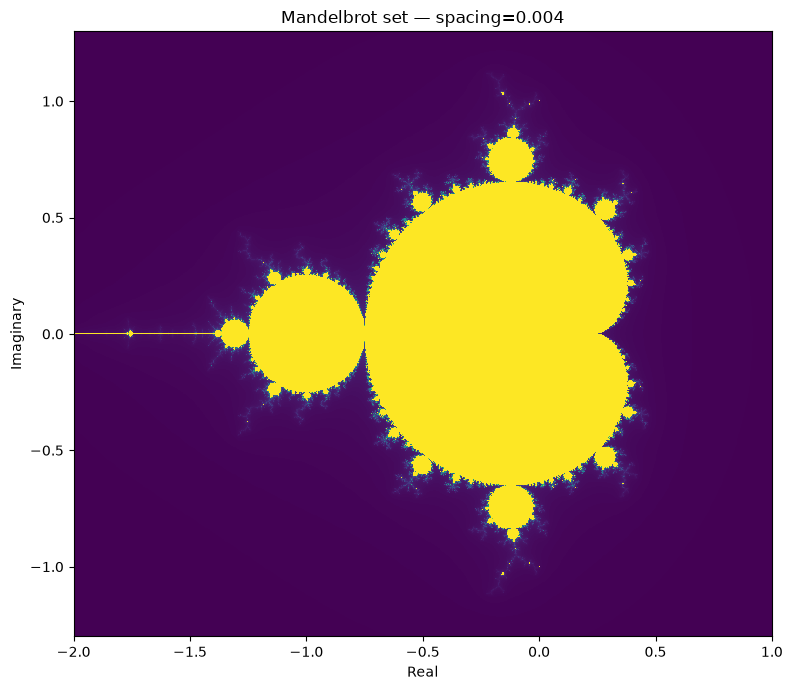

In [7]:
# Mandelbrot set
mandelbrot = escape_time_fractal(
    MANDEL_X_MIN, MANDEL_X_MAX,
    MANDEL_Y_MIN, MANDEL_Y_MAX,
    MANDEL_SPACING,
    max_iter=MANDEL_MAX_ITER,
    escape_radius=ESCAPE_RADIUS,
    mode="mandelbrot"
)

show_fractal(
    mandelbrot,
    MANDEL_X_MIN, MANDEL_X_MAX,
    MANDEL_Y_MIN, MANDEL_Y_MAX,
    f"Mandelbrot set — spacing={MANDEL_SPACING}"
)


## High-resolution zoom demonstration

A useful example is the **Seahorse Valley** region near \(-0.75+0.1i\). Smaller spacing gives more pixels and therefore more detail, but it also increases computation and memory use.

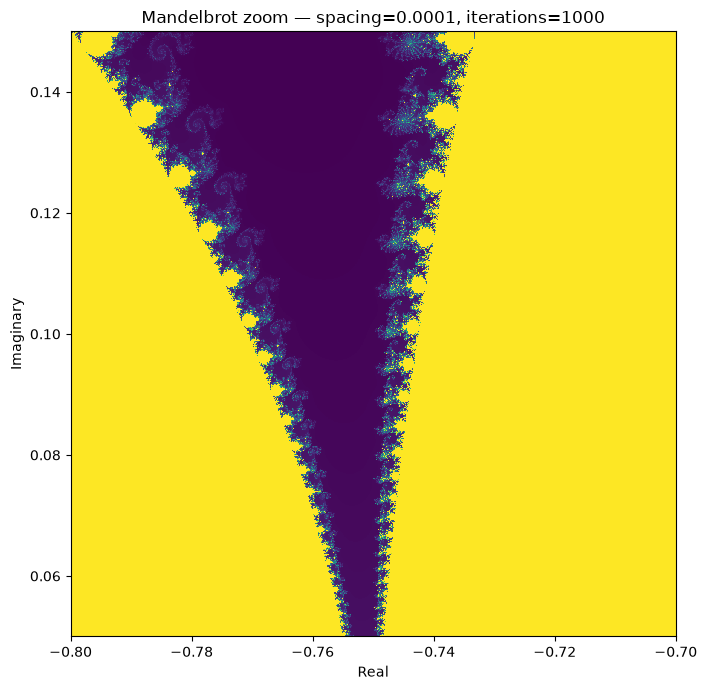

In [17]:
# =========================
# MANDELBROT ZOOM — DEMO CONTROLS
# =========================

ZOOM_X_MIN, ZOOM_X_MAX = -0.80, -0.70
ZOOM_Y_MIN, ZOOM_Y_MAX = 0.05, 0.15

ZOOM_SPACING = 0.0001     # increase if this is too slow on the demo machine
ZOOM_MAX_ITER = 1000

mandelbrot_zoom = escape_time_fractal(
    ZOOM_X_MIN, ZOOM_X_MAX,
    ZOOM_Y_MIN, ZOOM_Y_MAX,
    ZOOM_SPACING,
    max_iter=ZOOM_MAX_ITER,
    escape_radius=ESCAPE_RADIUS,
    mode="mandelbrot"
)

show_fractal(
    mandelbrot_zoom,
    ZOOM_X_MIN, ZOOM_X_MAX,
    ZOOM_Y_MIN, ZOOM_Y_MAX,
    f"Mandelbrot zoom — spacing={ZOOM_SPACING}, iterations={ZOOM_MAX_ITER}"
)


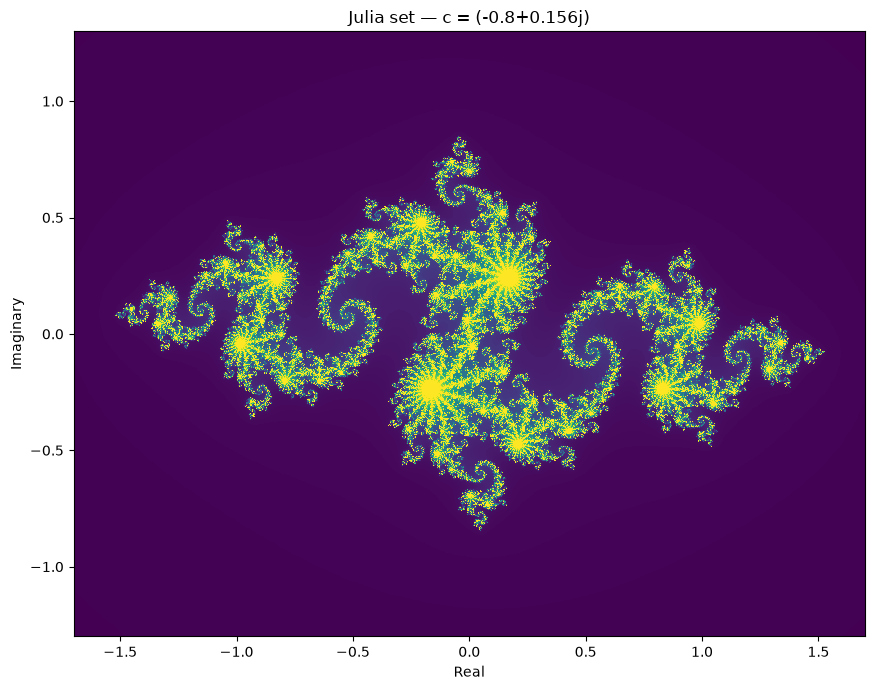

In [9]:
julia = escape_time_fractal(
    JULIA_X_MIN, JULIA_X_MAX,
    JULIA_Y_MIN, JULIA_Y_MAX,
    JULIA_SPACING,
    max_iter=JULIA_MAX_ITER,
    escape_radius=ESCAPE_RADIUS,
    mode="julia",
    julia_c=JULIA_C
)

show_fractal(
    julia,
    JULIA_X_MIN, JULIA_X_MAX,
    JULIA_Y_MIN, JULIA_Y_MAX,
    f"Julia set — c = {JULIA_C}"
)


### Part 2 demonstration explanation

For the **Mandelbrot set**, the grid position is the constant \(c\), while every point starts from \(z_0=0\).

For the **Julia set**, the grid position is instead the starting value \(z_0\), while `JULIA_C` is held fixed for the whole image. That small change is the key mathematical difference between the two implementations.

Good Julia constants to try live include:
- `complex(-0.8, 0.156)`
- `complex(-0.4, 0.6)`
- `complex(0.285, 0.01)`

### AI-use note for Part 2

Example prompt used:

> Implement an escape-time Mandelbrot set in PyTorch so the repeated complex-number iteration can run on a GPU. Then modify it into a Julia set and expose the viewing bounds, resolution, iteration count and Julia constant as variables.

The generated idea was then reorganised so the same PyTorch function handles both fractals and the demonstration parameters are isolated at the top of the section.

# Part 3 — Fractal implementation: Barnsley fern

For Part 3, this notebook uses a **Barnsley fern**, which is substantially different from the Mandelbrot/Julia escape-time family.

The fern is generated by an **iterated function system (IFS)**. At each step, one of four affine transformations is selected with a specified probability. Repeated application of these transformations produces the fern shape.

To make PyTorch a major computational component rather than merely using it for storage, the implementation below evolves **many independent trajectories in parallel** on the selected device.

The notebook also includes a **box-counting fractal-dimension estimate** as additional analysis.

In [10]:
# =========================
# PART 3 — DEMO CONTROLS
# =========================

FERN_NUM_CHAINS = 25_000       # independent trajectories evolved in parallel
FERN_STEPS = 350               # points retained per chain after burn-in
FERN_BURN_IN = 30              # initial transient steps discarded
FERN_SEED = 7

FERN_POINT_SIZE = 0.03
FERN_ALPHA = 0.35

# Standard Barnsley probabilities.
# These can be changed during the demo, but should sum to 1.
FERN_PROBABILITIES = torch.tensor(
    [0.01, 0.85, 0.07, 0.07],
    dtype=torch.float32
)

# Each row represents:
# x' = a*x + b*y + e
# y' = c*x + d*y + f
FERN_TRANSFORMS = torch.tensor([
    [0.00,  0.00,  0.00, 0.16, 0.00, 0.00],
    [0.85,  0.04, -0.04, 0.85, 0.00, 1.60],
    [0.20, -0.26,  0.23, 0.22, 0.00, 1.60],
    [-0.15, 0.28,  0.26, 0.24, 0.00, 0.44],
], dtype=torch.float32)


In [11]:
def generate_barnsley_fern(
    num_chains=25_000,
    steps=350,
    burn_in=30,
    probabilities=FERN_PROBABILITIES,
    transforms=FERN_TRANSFORMS,
    seed=7
):
    """Generate Barnsley-fern points with many PyTorch trajectories in parallel."""

    if not torch.isclose(probabilities.sum(), torch.tensor(1.0), atol=1e-5):
        raise ValueError("FERN_PROBABILITIES must sum to 1.")

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    probabilities = probabilities.to(device)
    transforms = transforms.to(device)

    # One x-y state per trajectory.
    x = torch.zeros(num_chains, device=device)
    y = torch.zeros(num_chains, device=device)

    saved_points = []

    for step in range(burn_in + steps):
        # Select one affine map for every trajectory simultaneously.
        choice = torch.multinomial(
            probabilities,
            num_samples=num_chains,
            replacement=True
        )

        t = transforms[choice]
        a, b, c, d, e, f = [t[:, i] for i in range(6)]

        new_x = a * x + b * y + e
        new_y = c * x + d * y + f
        x, y = new_x, new_y

        if step >= burn_in:
            saved_points.append(torch.stack((x, y), dim=1))

    points = torch.cat(saved_points, dim=0)
    return points.detach().cpu().numpy()


Generated 8,750,000 points.


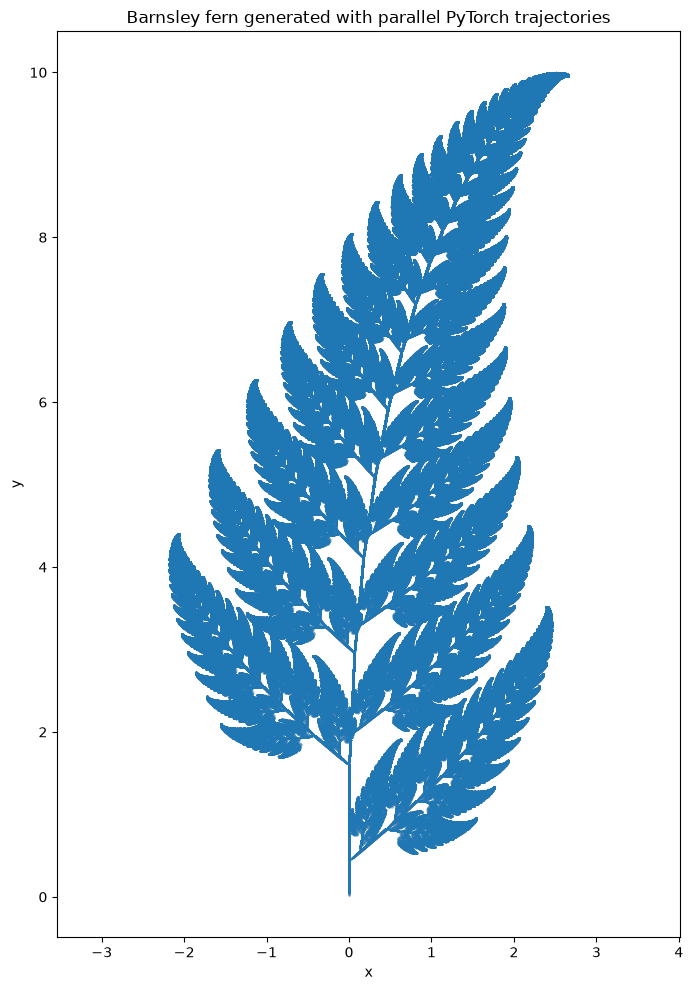

In [12]:
fern_points = generate_barnsley_fern(
    num_chains=FERN_NUM_CHAINS,
    steps=FERN_STEPS,
    burn_in=FERN_BURN_IN,
    probabilities=FERN_PROBABILITIES,
    transforms=FERN_TRANSFORMS,
    seed=FERN_SEED
)

print(f"Generated {len(fern_points):,} points.")

plt.figure(figsize=(7, 10))
plt.scatter(
    fern_points[:, 0],
    fern_points[:, 1],
    s=FERN_POINT_SIZE,
    alpha=FERN_ALPHA
)
plt.title("Barnsley fern generated with parallel PyTorch trajectories")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.tight_layout()
plt.show()


## Why the fern forms

Each affine map has a different role:

1. A rare transformation creates the **stem**.
2. The dominant transformation repeatedly shrinks, rotates and moves points upward, creating the main sequence of leaflets.
3. Two less common transformations generate the left and right side branches.

Because the same transformations are repeatedly applied to their own output, similar structures appear again at smaller scales — this is the self-similarity characteristic of a fractal.

The probabilities affect how densely different parts are sampled. The affine coefficients affect the actual geometry.

## Extra analysis — box-counting dimension

A simple way to quantify fractal complexity is to estimate the **box-counting dimension**.

If a grid of box width \(\epsilon\) requires \(N(\epsilon)\) occupied boxes to cover the fractal, then approximately

\[
N(\epsilon) \propto \epsilon^{-D}.
\]

Taking logarithms gives

\[
\log N(\epsilon) \approx D\log(1/\epsilon)+C,
\]

so the slope of a log-log plot estimates the fractal dimension \(D\).

This is an empirical estimate rather than an exact symbolic dimension.

In [13]:
# =========================
# BOX-COUNTING — DEMO CONTROLS
# =========================

# Use a random subset to keep the dimension estimate fast.
BOXCOUNT_MAX_POINTS = 1_000_000

# Number of grid divisions along each axis.
BOXCOUNT_GRID_SIZES = np.array([16, 24, 32, 48, 64, 96, 128, 192, 256])


Estimated box-counting dimension: 1.833


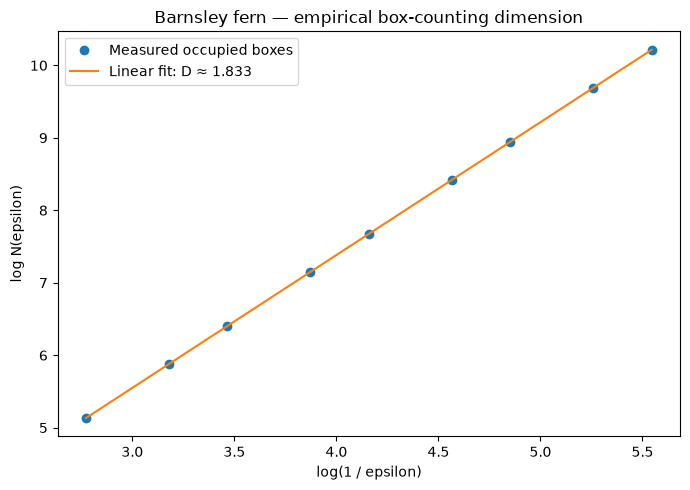

In [14]:
def box_counting_dimension(points, grid_sizes, max_points=1_000_000, seed=123):
    rng = np.random.default_rng(seed)

    if len(points) > max_points:
        idx = rng.choice(len(points), size=max_points, replace=False)
        pts = points[idx]
    else:
        pts = points

    # Normalise into [0, 1] x [0, 1].
    mins = pts.min(axis=0)
    maxs = pts.max(axis=0)
    norm = (pts - mins) / (maxs - mins + 1e-12)

    counts = []

    for n in grid_sizes:
        # Convert coordinates into integer box indices.
        ij = np.floor(norm * n).astype(np.int64)
        ij = np.clip(ij, 0, n - 1)

        occupied = np.unique(ij, axis=0)
        counts.append(len(occupied))

    counts = np.asarray(counts, dtype=float)

    x = np.log(grid_sizes.astype(float))      # log(1/epsilon), since epsilon ~ 1/n
    y = np.log(counts)

    slope, intercept = np.polyfit(x, y, 1)
    return slope, counts, x, y


estimated_dimension, occupied_counts, log_inv_eps, log_counts = box_counting_dimension(
    fern_points,
    BOXCOUNT_GRID_SIZES,
    max_points=BOXCOUNT_MAX_POINTS
)

print(f"Estimated box-counting dimension: {estimated_dimension:.3f}")

plt.figure(figsize=(7, 5))
plt.plot(log_inv_eps, log_counts, "o", label="Measured occupied boxes")

fit_y = estimated_dimension * log_inv_eps + (
    log_counts.mean() - estimated_dimension * log_inv_eps.mean()
)
plt.plot(log_inv_eps, fit_y, label=f"Linear fit: D ≈ {estimated_dimension:.3f}")

plt.xlabel("log(1 / epsilon)")
plt.ylabel("log N(epsilon)")
plt.title("Barnsley fern — empirical box-counting dimension")
plt.legend()
plt.tight_layout()
plt.show()


### Part 3 demonstration explanation

During the demo, useful variables to change are:
- `FERN_NUM_CHAINS` and `FERN_STEPS`: change the number of generated points and runtime.
- `FERN_PROBABILITIES`: change how frequently the four transformations are selected.
- `FERN_TRANSFORMS`: change the actual affine geometry.
- `FERN_SEED`: changes the sampled point sequence while preserving the same overall fractal.
- `BOXCOUNT_GRID_SIZES`: changes the scales used in the dimension estimate.

The major PyTorch parallelism is in the fern generator: every iteration updates thousands of independent trajectories simultaneously using tensor operations.

# Part 3 Git / GitHub checklist

The notebook can provide the fractal implementation, but the Git/GitHub component still needs to be completed on your own account.

Before demonstrating Part 3:

- Complete the required **Introduction to Version Control with Git** short course.
- Create a GitHub repository for the fractal project.
- Put this notebook (or a cleaned `.py` version of the fern code) in the repository.
- Make several sensible commits rather than one final dump, for example:
  1. `Initial Barnsley fern implementation`
  2. `Add adjustable demo parameters`
  3. `Add box-counting dimension analysis`
  4. `Improve plots and documentation`
- Push the commits to GitHub.
- Be prepared to explain:
  - what each affine transformation does;
  - where PyTorch parallelism is being used;
  - what changing the probabilities does;
  - how the box-counting dimension is estimated.

Because AI was used to assist with this notebook, keep the **AI-use notes/prompts** above in the submitted project or copy them into the repository README as required by the lab specification.